Expected annual arrivals (mean) = 621.7 EV/year
Realized annual arrivals = 587 EV/year (seed=12345)
Saved:
 - /content/outputs/ev_hourly_profile_8760_queue.csv
 - /content/outputs/ev_hourly_profile_8760_queue.txt


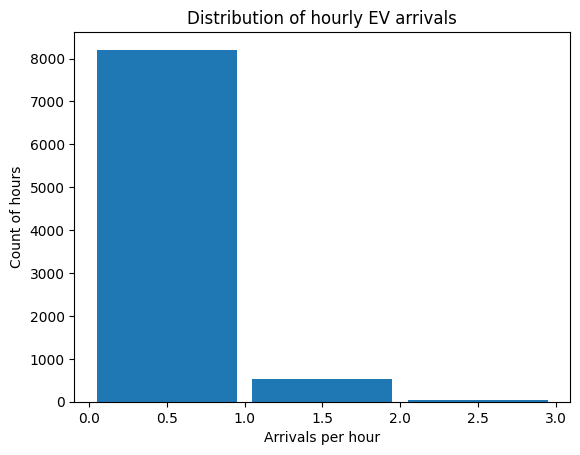

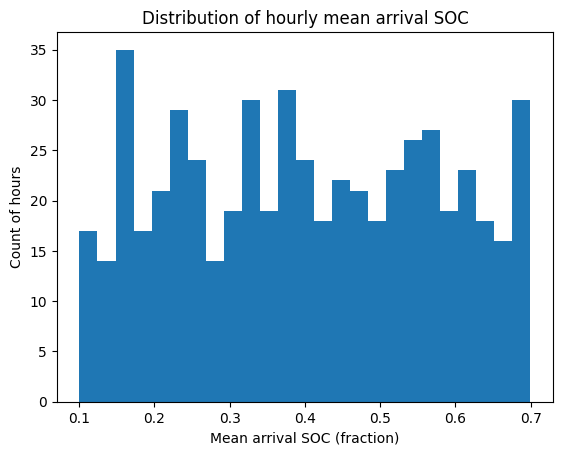

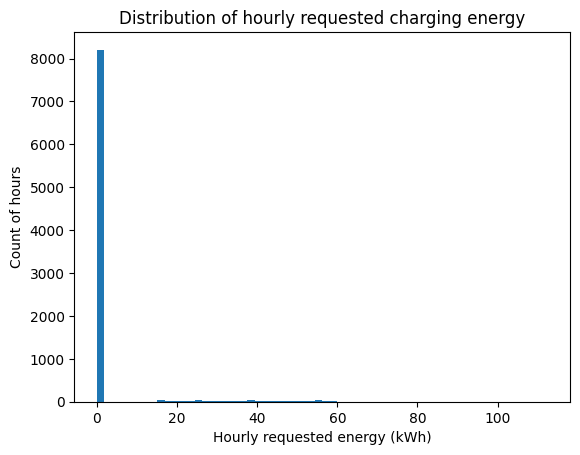

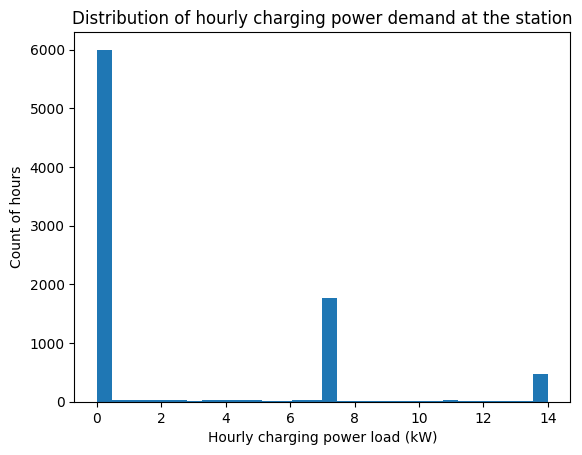

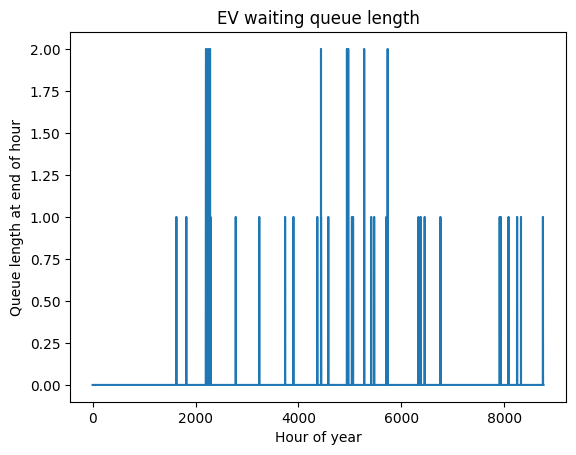

In [8]:
# ======================================================================
# Google Colab: Hourly EV arrivals (NHPP Poisson) + SOC + energy-to-charge
# + charging station hourly power load for microgrid simulation
# + FIFO waiting queue
#
# Assumptions:
#   - All EVs have the SAME battery capacity: 75 kWh
#   - Arrival SOC is Uniform between 10% and 70%
#   - Charging target SOC is SOC_TARGET
#   - Station has 2 connectors, 7 kW each
#   - EVs continue charging hour by hour until reaching 100% SOC
#   - If both connectors are busy, new EVs wait in a FIFO queue
#
# Outputs:
#   arrivals                  -> EV that arrive in that hour (served by Poisson cap)
#   soc_mean                  -> mean SOC of arriving EVs in that hour
#   energy_kWh                -> total requested energy of arriving EVs that hour
#   power_load_kW             -> actual hourly charging power for the microgrid
#   active_connectors         -> number of occupied connectors in that hour
#   queue_length_end          -> queue length at the end of the hour
#   arrivals_connected        -> EV that actually start charging in that hour
#
# Files:
#   - ev_hourly_profile_8760_queue.csv
#   - ev_hourly_profile_8760_queue.txt
# ======================================================================

import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from collections import deque

# --------------------------
# 0) Reproducibility
# --------------------------
SEED = 12345
rng = np.random.default_rng(SEED)

# --------------------------
# 1) Simulation settings
# --------------------------
YEAR = 2026
N_HOURS = 8760
START = f"{YEAR}-01-01 00:00:00"

MAX_CHARGERS = 2
CHARGER_POWER_KW = 7.0
BATTERY_KWH = 75.0
SOC_MIN = 0.10
SOC_MAX = 0.70
SOC_TARGET = 0.90

# --------------------------
# 2) Define lambda(t) model
# --------------------------
lambda_24 = np.array([
    0.01, 0.01, 0.01, 0.01, 0.02, 0.03,
    0.06, 0.10, 0.12, 0.10, 0.08, 0.06,
    0.05, 0.05, 0.06, 0.08, 0.10, 0.12,
    0.14, 0.12, 0.08, 0.05, 0.03, 0.02
], dtype=float)

dow_factor = np.array([0.90, 0.90, 0.95, 1.00, 1.05, 1.10, 1.05], dtype=float)

month_factor = np.array([
    1.00, 1.00, 1.00, 1.05, 1.00, 1.35,
    1.55, 1.45, 1.05, 1.00, 1.00, 1.05
], dtype=float)

TARGET_ANNUAL_ARRIVALS = None

EASTER_FACTOR = 1.5
EASTER_START = '2026-03-30'
EASTER_END = '2026-04-06'

# --------------------------
# 3) Build hourly calendar
# --------------------------
dt_index = pd.date_range(start=START, periods=N_HOURS, freq="h")
df = pd.DataFrame({"datetime": dt_index})
df["hour"] = np.arange(N_HOURS)
df["hod"] = df["datetime"].dt.hour
df["dow"] = df["datetime"].dt.dayofweek
df["month"] = df["datetime"].dt.month

# --------------------------
# 4) Compute lambda(t)
# --------------------------
df["lambda_base"] = lambda_24[df["hod"].to_numpy()]
df["lambda_dow"] = dow_factor[df["dow"].to_numpy()]
df["lambda_month"] = month_factor[(df["month"] - 1).to_numpy()]

df["lambda_ev_per_h"] = df["lambda_base"] * df["lambda_dow"] * df["lambda_month"]

df["lambda_event"] = 1.0
if EASTER_START is not None and EASTER_END is not None:
    mask = (df["datetime"] >= EASTER_START) & (df["datetime"] <= EASTER_END)
    df.loc[mask, "lambda_event"] = float(EASTER_FACTOR)

df["lambda_ev_per_h"] *= df["lambda_event"]

if TARGET_ANNUAL_ARRIVALS is not None:
    expected_before = df["lambda_ev_per_h"].sum()
    if expected_before <= 0:
        raise ValueError("Expected arrivals before scaling is <= 0; check lambda inputs.")
    scale = TARGET_ANNUAL_ARRIVALS / expected_before
    df["lambda_ev_per_h"] *= scale
    print(f"Applied global scaling factor = {scale:.4f} to match TARGET_ANNUAL_ARRIVALS={TARGET_ANNUAL_ARRIVALS}")
else:
    print(f"Expected annual arrivals (mean) = {df['lambda_ev_per_h'].sum():.1f} EV/year")

# --------------------------
# 5) Generate Poisson arrivals per hour
# --------------------------
lam = df["lambda_ev_per_h"].to_numpy()
arrivals_raw = rng.poisson(lam=lam)

# Mantengo arrivals sin truncar a conectores, para que la cola reciba todos los que llegan
df["arrivals_raw"] = arrivals_raw
df["arrivals"] = arrivals_raw

print(f"Realized annual arrivals = {df['arrivals'].sum()} EV/year (seed={SEED})")

# --------------------------
# 6) Assign SOC and requested energy for each arriving EV
# --------------------------
soc_mean = np.zeros(N_HOURS, dtype=float)
energy_kWh = np.zeros(N_HOURS, dtype=float)

# Lista de solicitudes por hora: cada elemento es una lista de dicts
# {'energy_remaining': ..., 'soc_arrival': ...}
hourly_ev_requests = []

for h in range(N_HOURS):
    n = int(arrivals_raw[h])

    if n <= 0:
        soc_mean[h] = 0.0
        energy_kWh[h] = 0.0
        hourly_ev_requests.append([])
        continue

    soc_i = rng.uniform(SOC_MIN, SOC_MAX, size=n)
    soc_mean[h] = float(np.mean(soc_i))

    delta = np.maximum(0.0, SOC_TARGET - soc_i)
    ev_energy_i = BATTERY_KWH * delta
    energy_kWh[h] = float(np.sum(ev_energy_i))

    requests_h = []
    for i in range(n):
        requests_h.append({
            "energy_remaining": float(ev_energy_i[i]),
            "soc_arrival": float(soc_i[i]),
        })
    hourly_ev_requests.append(requests_h)

df["soc_mean"] = soc_mean
df["energy_kWh"] = energy_kWh

# --------------------------
# 6B) Simulate charging station with FIFO queue
# --------------------------
# Cada conector almacena el EV actualmente conectado o None
connectors = [None] * MAX_CHARGERS

# Cola FIFO de EV esperando
waiting_queue = deque()

power_load_kW = np.zeros(N_HOURS, dtype=float)
active_connectors = np.zeros(N_HOURS, dtype=int)
queue_length_start = np.zeros(N_HOURS, dtype=int)
queue_length_end = np.zeros(N_HOURS, dtype=int)
arrivals_connected = np.zeros(N_HOURS, dtype=int)
arrivals_queued = np.zeros(N_HOURS, dtype=int)
completed_sessions = np.zeros(N_HOURS, dtype=int)

for h in range(N_HOURS):
    # 1) Registrar cola al inicio de la hora
    queue_length_start[h] = len(waiting_queue)

    # 2) Agregar nuevos arribos a la cola
    new_requests = hourly_ev_requests[h]
    for req in new_requests:
        waiting_queue.append(req)
    arrivals_queued[h] = len(new_requests)

    # 3) Asignar EV de la cola a conectores libres
    connected_this_hour = 0
    for c in range(MAX_CHARGERS):
        if connectors[c] is None and len(waiting_queue) > 0:
            connectors[c] = waiting_queue.popleft()
            connected_this_hour += 1

    arrivals_connected[h] = connected_this_hour

    # 4) Cargar durante esta hora
    delivered_this_hour = 0.0
    active_this_hour = 0
    completed_this_hour = 0

    for c in range(MAX_CHARGERS):
        if connectors[c] is not None:
            active_this_hour += 1

            delivered = min(CHARGER_POWER_KW, connectors[c]["energy_remaining"])
            connectors[c]["energy_remaining"] -= delivered
            delivered_this_hour += delivered

            # Si terminó de cargar al final de la hora, libera el conector
            if connectors[c]["energy_remaining"] <= 1e-9:
                connectors[c] = None
                completed_this_hour += 1

    power_load_kW[h] = delivered_this_hour
    active_connectors[h] = active_this_hour
    completed_sessions[h] = completed_this_hour
    queue_length_end[h] = len(waiting_queue)

df["arrivals_connected"] = arrivals_connected
df["arrivals_queued"] = arrivals_queued
df["active_connectors"] = active_connectors
df["completed_sessions"] = completed_sessions
df["queue_length_start"] = queue_length_start
df["queue_length_end"] = queue_length_end
df["power_load_kW"] = power_load_kW

# --------------------------
# 7) Export results
# --------------------------
out_dir = Path("./outputs")
out_dir.mkdir(parents=True, exist_ok=True)

csv_path = out_dir / "ev_hourly_profile_8760_queue.csv"
txt_path = out_dir / "ev_hourly_profile_8760_queue.txt"

df_csv = df[[
    "hour",
    "arrivals",
    "soc_mean",
    "energy_kWh",
    "arrivals_connected",
    "arrivals_queued",
    "active_connectors",
    "completed_sessions",
    "queue_length_start",
    "queue_length_end",
    "power_load_kW"
]].copy()
df_csv.to_csv(csv_path, index=False)

# TXT para TRNSYS: conserva lo esencial
df_txt = df[[
    "hour",
    "arrivals",
    "soc_mean",
    "energy_kWh",
    "queue_length_end",
    "power_load_kW"
]].copy()
df_txt.to_csv(txt_path, index=False, sep="\t", header=False)

print("Saved:")
print(f" - {csv_path.resolve()}")
print(f" - {txt_path.resolve()}")

# --------------------------
# 8) Quick checks
# --------------------------
plt.figure()
plt.hist(df["arrivals"], bins=range(0, int(df["arrivals"].max()) + 2), rwidth=0.9)
plt.xlabel("Arrivals per hour")
plt.ylabel("Count of hours")
plt.title("Distribution of hourly EV arrivals")
plt.show()

plt.figure()
plt.hist(df.loc[df["arrivals"] > 0, "soc_mean"], bins=25)
plt.xlabel("Mean arrival SOC (fraction)")
plt.ylabel("Count of hours")
plt.title("Distribution of hourly mean arrival SOC")
plt.show()

plt.figure()
plt.hist(df["energy_kWh"], bins=60)
plt.xlabel("Hourly requested energy (kWh)")
plt.ylabel("Count of hours")
plt.title("Distribution of hourly requested charging energy")
plt.show()

plt.figure()
plt.hist(df["power_load_kW"], bins=30)
plt.xlabel("Hourly charging power load (kW)")
plt.ylabel("Count of hours")
plt.title("Distribution of hourly charging power demand at the station")
plt.show()

plt.figure()
plt.plot(df["hour"], df["queue_length_end"])
plt.xlabel("Hour of year")
plt.ylabel("Queue length at end of hour")
plt.title("EV waiting queue length")
plt.show()

# Task
Define Easter holiday parameters, setting `EASTER_FACTOR` to 1.5 and `EASTER_START` to "2026-03-30" and `EASTER_END` to "2026-04-06", then update the simulation code to incorporate these parameters, run the simulation, and visualize the impact of these changes on EV arrivals and charging station dynamics, particularly during the Easter period.

## Definir Parámetros de Vacaciones de Pascua

### Subtask:
Establecer el `EASTER_FACTOR` a un valor mayor que 1 (por ejemplo, 1.5) para simular un aumento en las llegadas durante el período de vacaciones. También se definirán las fechas de `EASTER_START` y `EASTER_END` para el año 2026, abarcando aproximadamente la semana de Pascua.


**Reasoning**:
The subtask requires setting specific values for `EASTER_FACTOR`, `EASTER_START`, and `EASTER_END` variables. I will create a code block to update these variables in the existing simulation settings.



In [7]:
EASTER_FACTOR = 1.5
EASTER_START = '2026-03-30'
EASTER_END = '2026-04-06'